## Introduction
This coursework investigates how Principal Component Analysis (PCA) impacts neural network performance using the MNIST dataset. By comparing a baseline model trained on 784-pixel images against networks retrained on compressed feature spaces (100 and 20 components), then the trade-offs between dimensionality reduction, computational efficiency, and classification accuracy were evaluated.

In [ ]:
# import essential libraries
import matplotlib.pyplot as plt
import numpy as np
import math

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

import matplotlib.style #Some style nonsense
import matplotlib as mpl #Some more style nonsense

from scipy import linalg

#Set default figure size
#mpl.rcParams['figure.figsize'] = [12.0, 8.0] #Inches... of course it is inches
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']=200 # dots per inch

#Useful for debugging problems
print(tf.__version__)

2.19.0


## Part 1
Train a neural netwaork for orinial MNIST dataset with accuracy above 95%.

In [ ]:
# load the original handwritten digit MNIST
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# normalising the datasets
train_images_norm = train_images/255.0
test_images_norm = test_images/255.0

# Set up the layers
model_1 = keras.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10)
])

# Compile the model with parameters
model_1.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer=tf.keras.optimizers.SGD(learning_rate=0.5),
              metrics=['accuracy'])

# train the network using train_images and run the training for 15 epochs to allow the model to learn the patterns
model_1.fit(train_images_norm, train_labels, batch_size = 100, epochs=15)

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8574 - loss: 0.4657
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9629 - loss: 0.1239
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9734 - loss: 0.0883
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9798 - loss: 0.0665
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9853 - loss: 0.0500
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9875 - loss: 0.0413
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9906 - loss: 0.0332
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9921 - loss: 0.0284
Epoch 9/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9937 - loss: 0.0234
Epoch 10/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9959 - loss: 0.0176
Epoch 11/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9966 - loss: 0.0155
Epoch 12/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

In [ ]:
# Test the performance of the trained network by using test_images
test_loss, test_acc = model_1.evaluate(test_images_norm, test_labels, verbose=2)
print(f"Test accuracy: {test_acc*100}%")

# save model_1 for PCA later
model_1.save('baseline_model.keras')

313/313 - 1s - 3ms/step - accuracy: 0.9794 - loss: 0.0714
Test accuracy: 97.93999791145325%


## Part 2
To perform PCA by using baseline model

In [ ]:
# define functions

def perform_pca(X):
    """
    To perform PCA for input data

    Args:
    X (numpy.ndarray): input data matrix in (N, p), where N is the number of samples and p is the number of features.

    Return:
    vecs (numpy.ndarray): eigenvector matrix in (p, p), where p is the number of features.
    vals (numpy.ndarray): eigenvalue vector in (p,), where p is the number of features.
    X_centered (numpy.ndarray): centered data matrix in (N, p), where N is the number of samples
    mu (numpy.ndarray): mean vector in (p,), where p is the number of features.
    """

    # Zero mean
    mu = np.mean(X, axis=0)
    X_centered = X - mu

    # get covariance matrix
    # rowvar=False, represents row is sample and column is features
    rho = np.cov(X_centered, rowvar=False)

    #  Eigendecomposition
    # vals is eigenvalue，vecs is eigenvector matrix
    vals, vecs = np.linalg.eigh(rho)

    # sort
    vecs=np.flip(vecs, axis = 1)
    vals=np.flip(vals)

    return vecs, vals, X_centered, mu

def reconstruct_data(X_data, vecs_train, mu_train, n_components):
    """
    reduce the dimension and reconstrcut the data using the first N principle components

    Args:
    X_data (numpy.ndarray): input data matrix in (N, p), where N is the number of samples
    vecs_train (numpy.ndarray): eigenvector matrix in (p, p), where p is the number of features.
    mu_train (numpy.ndarray): mean vector in (p,), where p is the number of features.
    n_components (int): the number of principle components to retain.

    Returns:
        X_reconstructed (numpy.ndarray): data after reconstruction in (N, 784)
    """
    # Cut the first n principle components
    V_n = vecs_train[:, :n_components]

    # centralise the data
    X_centered = X_data - mu_train

    # reduce the dimension from 784 to N
    Z = np.dot(X_centered, V_n)

    # recover the data form N_dimension to 784-D and add mu
    X_reconstructed = np.dot(Z, np.transpose(V_n)) + mu_train

    return X_reconstructed


(784,)


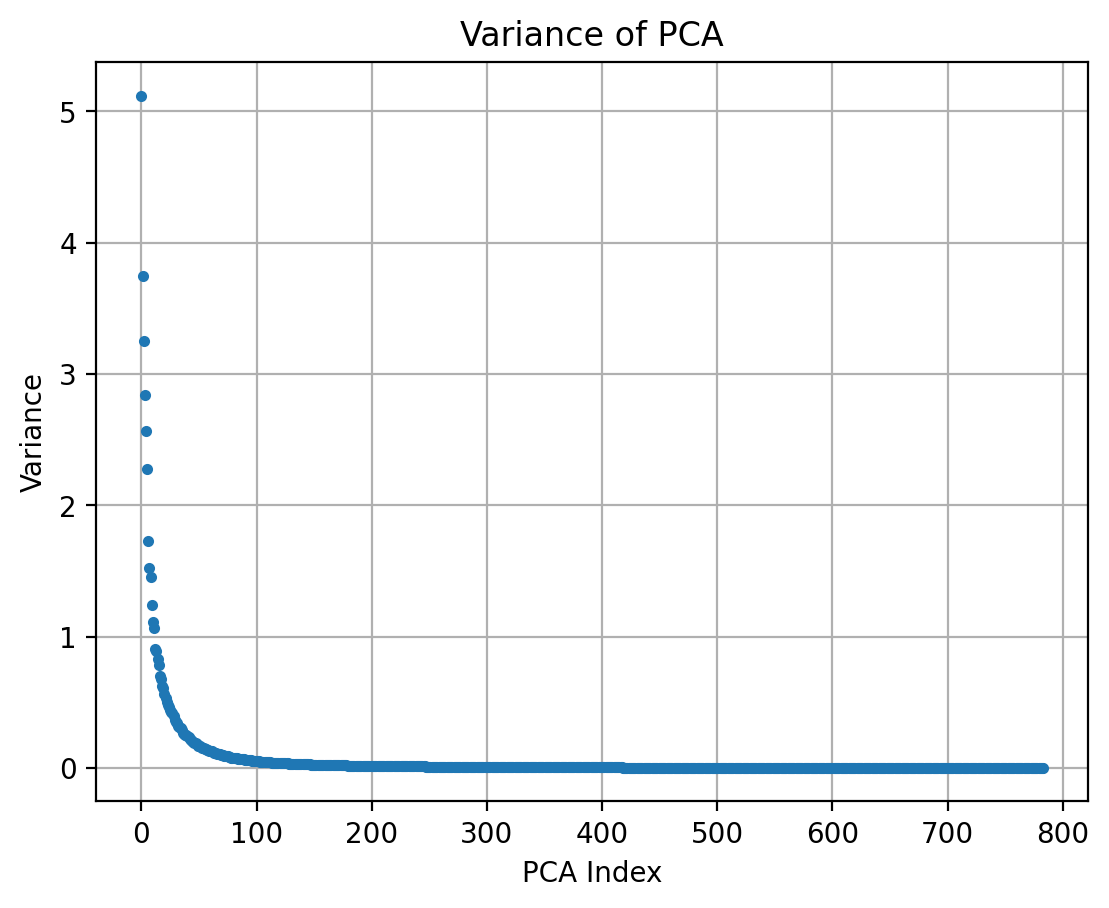

In [ ]:
X_train = train_images_norm.reshape(60000, 784)

vecs_train, vals_train, X_centered_train, mu_train = perform_pca(X_train)

print(np.shape(vals_train))
fig,ax=plt.subplots()
index=np.arange((np.shape(vals_train)[0]))
ax.plot(index,vals_train.real,".")
ax.set_xlabel("PCA Index")
ax.set_ylabel("Variance")
ax.set_title("Variance of PCA")
ax.grid()

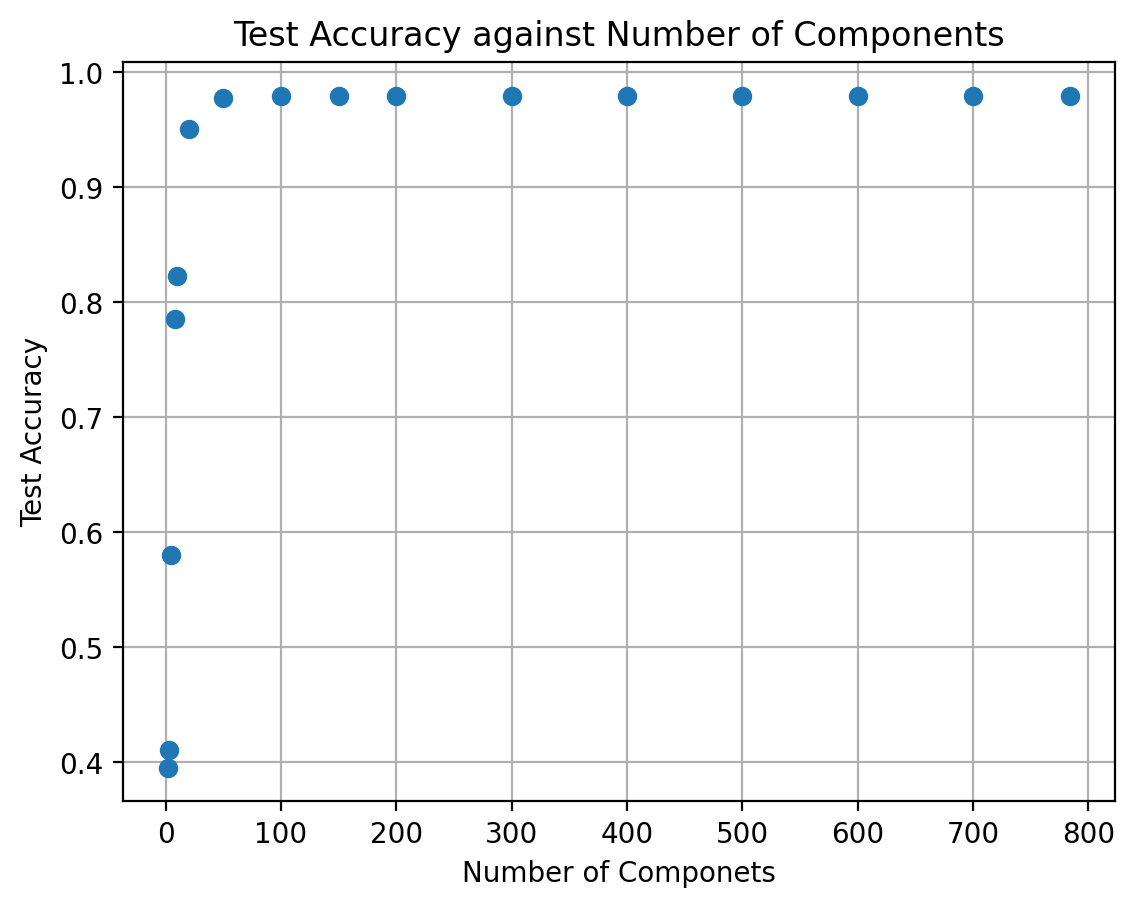

In [ ]:
X_test = test_images_norm.reshape(10000, 784)
baseline_model = tf.keras.models.load_model('baseline_model.keras')

n_componets = [2, 3, 5, 8, 10, 20, 50, 100, 150, 200, 300, 400, 500, 600, 700, 784]
accuracy = []

for n in n_componets:
    X_reconstructed = reconstruct_data(X_test, vecs_train, mu_train, n) # reconstruct data

    X_test_images_reconstructed = np.reshape(X_reconstructed, (10000, 28, 28)) # reconstruct to image

    test_loss, test_acc = baseline_model.evaluate(X_test_images_reconstructed, test_labels, verbose = 0) # examine performance
    accuracy.append(test_acc)

fig, ax = plt.subplots()
ax.plot(n_componets, accuracy, 'o')
ax.set_xlabel('Number of Componets')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy against Number of Components')
ax.grid(True)


## Part 3
Reconstruct the dataset by first 100 principle components and retrain a neural netwrok with it

In [ ]:
# reconstruct the training dataset via first 100 principle components
X_train_reconstructed_100 = reconstruct_data(X_train, vecs_train, mu_train, 100)
X_train_image_100 = np.reshape(X_train_reconstructed_100, (60000, 28, 28)) # convert data from (60000, 784) to (60000,28,28)

# Retrain a neural network
model_100 = keras.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10)
])

# Compile the model_100 with parameters
model_100.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer=tf.keras.optimizers.SGD(learning_rate=0.5),
              metrics=['accuracy'])

# Training the network with data after reduction of dimensions
model_100.fit(X_train_image_100, train_labels, batch_size=100, epochs=15)

# save model_100 for PCA later
model_100.save('model_100.keras')

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8586 - loss: 0.4584
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9625 - loss: 0.1271
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9737 - loss: 0.0879
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9775 - loss: 0.0721
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9822 - loss: 0.0599
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9842 - loss: 0.0532
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9858 - loss: 0.0449
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9881 - loss: 0.0380
Epoch 9/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9898 - loss: 0.0344
Epoch 10/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9915 - loss: 0.0290
Epoch 11/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9923 - loss: 0.0272
Epoch 12/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

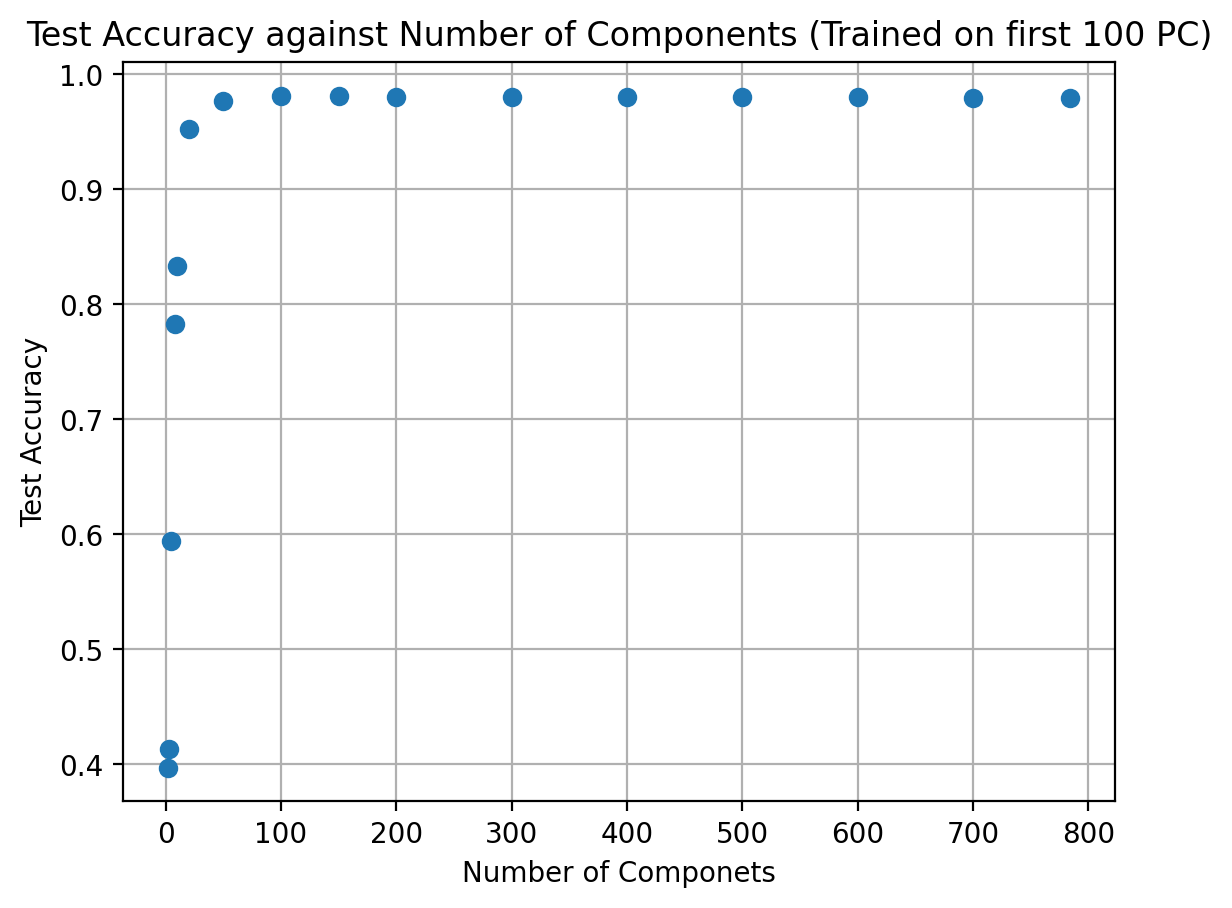

In [ ]:
accuracy_100 = []

for n in n_componets:
    X_reconstructed = reconstruct_data(X_test, vecs_train, mu_train, n)

    X_test_images_reconstructed = np.reshape(X_reconstructed, (10000, 28, 28))

    test_loss, test_acc = model_100.evaluate(X_test_images_reconstructed, test_labels, verbose = 0)
    accuracy_100.append(test_acc)

fig, ax = plt.subplots()
ax.plot(n_componets, accuracy_100, 'o')
ax.set_xlabel('Number of Componets')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy against Number of Components (Trained on first 100 PC)')
ax.grid(True)

## Part 4
Retrain the nework with first 20 principle componets, and make comparison with accuracy from other models trained on different PC (20, 100, 784)

In [ ]:
# reconstruct the training dataset via first 20 principle components
X_train_reconstructed_20 = reconstruct_data(X_train, vecs_train, mu_train, 20)
X_train_image_20 = np.reshape(X_train_reconstructed_20, (60000, 28, 28)) # convert data from (60000, 784) to (60000,28,28)

# Retrain a neural network
model_20 = keras.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10)
])

# Compile the model_20 with parameters
model_20.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer=tf.keras.optimizers.SGD(learning_rate=0.5),
              metrics=['accuracy'])

# Training the network with data after reduction of dimensions
model_20.fit(X_train_image_20, train_labels, batch_size=100, epochs=15)

# save model_100 for PCA later
model_20.save('model_20.keras')

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8367 - loss: 0.5173
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9474 - loss: 0.1711
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9582 - loss: 0.1331
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9634 - loss: 0.1209
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9663 - loss: 0.1059
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9674 - loss: 0.1006
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9682 - loss: 0.0993
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9695 - loss: 0.0936
Epoch 9/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9714 - loss: 0.0885
Epoch 10/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9730 - loss: 0.0834
Epoch 11/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9751 - loss: 0.0804
Epoch 12/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

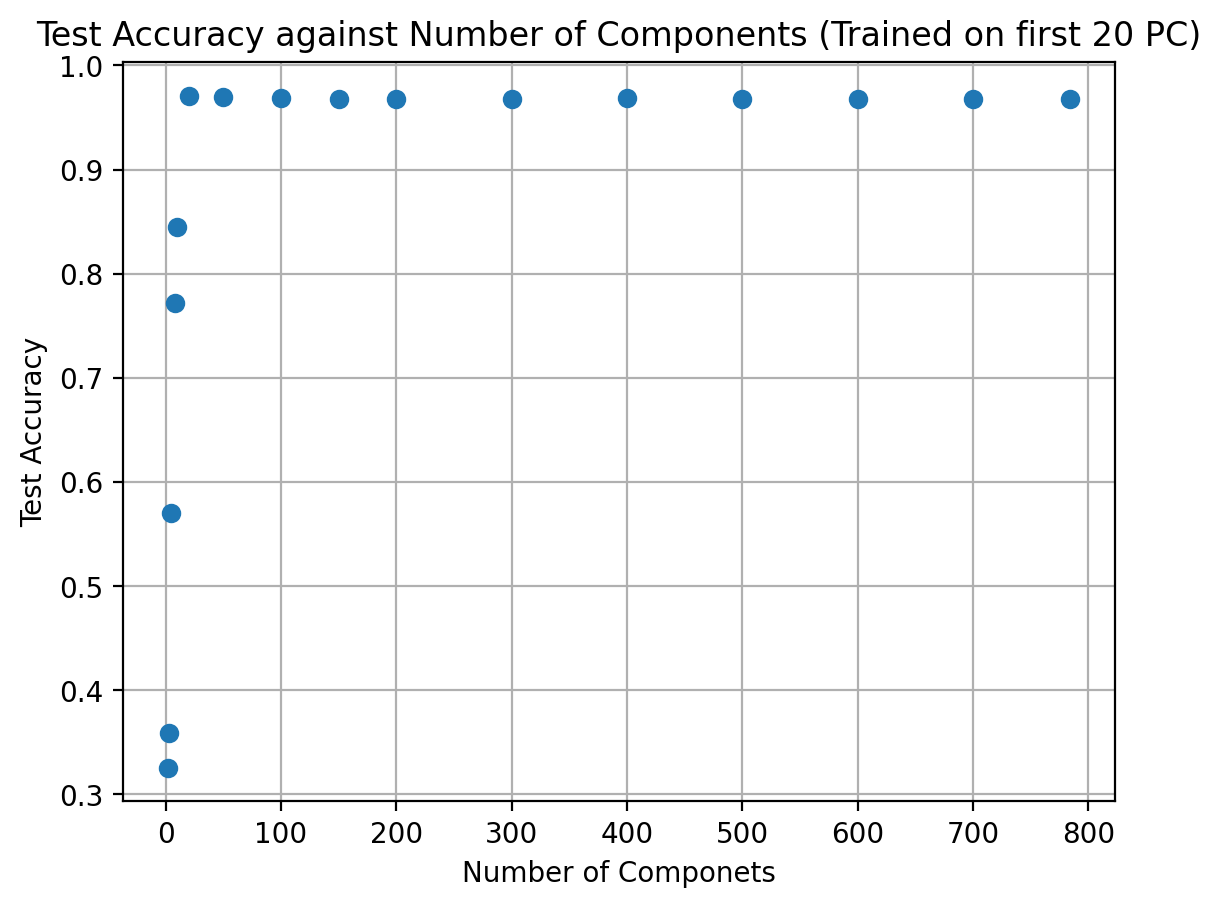

In [ ]:
accuracy_20 = []

for n in n_componets:
    X_reconstructed = reconstruct_data(X_test, vecs_train, mu_train, n)

    X_test_images_reconstructed = np.reshape(X_reconstructed, (10000, 28, 28))

    test_loss, test_acc = model_20.evaluate(X_test_images_reconstructed, test_labels, verbose = 0)
    accuracy_20.append(test_acc)

fig, ax = plt.subplots()
ax.plot(n_componets, accuracy_20, 'o')
ax.set_xlabel('Number of Componets')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy against Number of Components (Trained on first 20 PC)')
ax.grid(True)

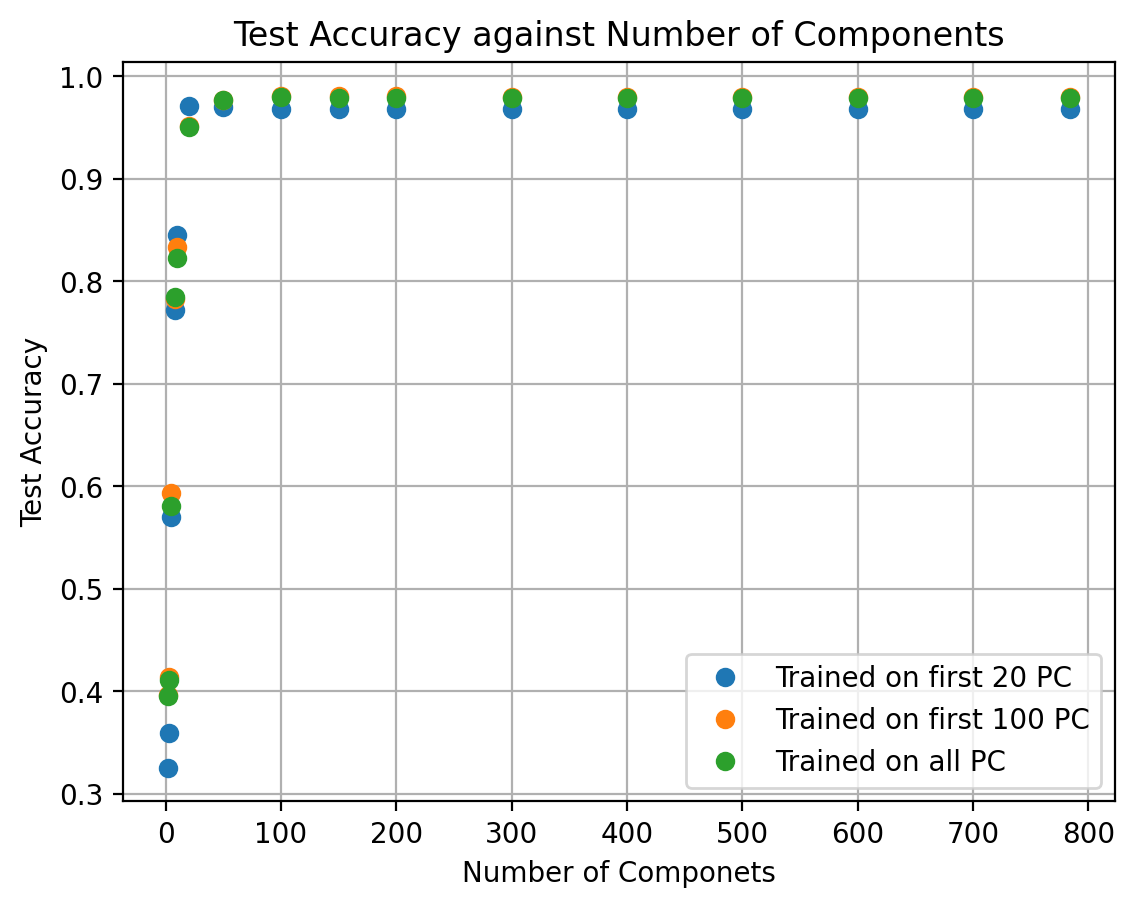

In [ ]:
# Comparing the accuracy of models trained under different PC (20, 100, 784)
fig, ax = plt.subplots()
ax.plot(n_componets, accuracy_20, 'o', label='Trained on first 20 PC')
ax.plot(n_componets, accuracy_100, 'o', label='Trained on first 100 PC')
ax.plot(n_componets, accuracy, 'o', label='Trained on all PC')
ax.set_xlabel('Number of Componets')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy against Number of Components')
ax.grid(True)
ax.legend(frameon= True)
plt.show()

## Discussion
The results highlight the impact of PCA dimensionality reduction on neural network robustness. At low component counts (under 20), the model trained on just 20 components significantly outperforms the baseline model. This shows that networks adapt highly to their specific training data distributions and learn to rely on compressed features. However, as retained components reach 100, all models rapidly converge to near-maximum accuracy. This confirms that the first 100 principal components capture almost all essential variance needed for MNIST classification, rendering the remaining dimensions largely redundant.